**Import Library**

In [1]:
from pathlib import Path
from PIL import Image, ImageStat, ImageFilter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import random
import os

In [2]:
DATA_DIR = Path("../data/split")
RESULT_DIR = Path("../results/eda")
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]

CLASSES = [
    "biological",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

print("DATA_DIR:", DATA_DIR.exists())
print("RESULT_DIR:", RESULT_DIR.exists())

DATA_DIR: True
RESULT_DIR: True


**Cek struktur folder**

In [ ]:
for split in SPLITS:
    split_path = DATA_DIR / split
    print(f"\nCek folder: {split_path}")

    if not split_path.exists():
        print("Folder split tidak ditemukan.")
        continue

    for nama_kelas in CLASSES:
        class_path = split_path / nama_kelas

        if class_path.exists():
            print(f"  {nama_kelas}: ada")
        else:
            print(f"  {nama_kelas}: TIDAK ADA")


Cek folder: ..\data\split\train
  biological: ada
  cardboard: ada
  glass: ada
  metal: ada
  paper: ada
  plastic: ada

Cek folder: ..\data\split\val
  biological: ada
  cardboard: ada
  glass: ada
  metal: ada
  paper: ada
  plastic: ada

Cek folder: ..\data\split\test
  biological: ada
  cardboard: ada
  glass: ada
  metal: ada
  paper: ada
  plastic: ada


**Ambil metadata**

In [4]:
def hitung_md5(path_file):
    """Menghitung hash MD5 untuk mendeteksi duplikat gambar"""
    
    hash_md5 = hashlib.md5()
    with open(path_file, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


def hitung_sharpness_sederhana(img):
    """
    Mengukur ketajaman gambar secara sederhana
    Caranya pakai filter edge, lalu dihitung variansinya
    Nilai kecil = gambar lebih blur
    """
    
    grayscale = img.convert("L")
    edge = grayscale.filter(ImageFilter.FIND_EDGES)
    arr = np.array(edge)
    return arr.var()


data = []

for split in SPLITS:
    for nama_kelas in CLASSES:
        folder_kelas = DATA_DIR / split / nama_kelas

        if not folder_kelas.exists():
            continue

        for path_gambar in folder_kelas.iterdir():
            if path_gambar.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            info = {
                "split": split,
                "kelas": nama_kelas,
                "nama_file": path_gambar.name,
                "path": str(path_gambar),
                "ekstensi": path_gambar.suffix.lower(),
                "ukuran_file_kb": path_gambar.stat().st_size / 1024
            }

            try:
                with Image.open(path_gambar) as img:
                    img_verify = img.copy()

                    width, height = img_verify.size
                    mode = img_verify.mode
                    format_file = img.format

                    # Konversi ke RGB supaya statistik warna konsisten
                    img_rgb = img_verify.convert("RGB")
                    arr = np.array(img_rgb)

                    brightness = arr.mean()
                    contrast = arr.std()
                    sharpness = hitung_sharpness_sederhana(img_rgb)

                    info.update({
                        "width": width,
                        "height": height,
                        "aspect_ratio": width / height if height != 0 else np.nan,
                        "mode": mode,
                        "format": format_file,
                        "brightness": brightness,
                        "contrast": contrast,
                        "sharpness": sharpness,
                        "corrupt": False,
                        "error": None,
                        "md5": hitung_md5(path_gambar)
                    })

            except Exception as e:
                info.update({
                    "width": np.nan,
                    "height": np.nan,
                    "aspect_ratio": np.nan,
                    "mode": None,
                    "format": None,
                    "brightness": np.nan,
                    "contrast": np.nan,
                    "sharpness": np.nan,
                    "corrupt": True,
                    "error": str(e),
                    "md5": None
                })

            data.append(info)

df = pd.DataFrame(data)

print("Jumlah gambar terbaca:", len(df))
df.head()

Jumlah gambar terbaca: 7709


,split,kelas,nama_file,path,ekstensi,ukuran_file_kb,width,height,aspect_ratio,mode,format,brightness,contrast,sharpness,corrupt,error,md5
0,train,biological,biological_1.jpg,..\data\split\train\biological\biological_1.jpg,.jpg,7.479492,259,194,1.335052,RGB,JPEG,136.686934,55.488280,2244.572708,False,None,eb50feb27d88c5b1c5bff86db574959b
1,train,biological,biological_100.jpg,..\data\split\train\biological\biological_100.jpg,.jpg,10.933594,259,194,1.335052,RGB,JPEG,98.431344,71.696301,2954.968870,False,None,ff8d67f71f4cac204417e65ffcce34c3
2,train,biological,biological_101.jpg,..\data\split\train\biological\biological_101.jpg,.jpg,12.242188,299,168,1.779762,RGB,JPEG,82.839637,59.082670,5766.572494,False,None,b0f7d147c381be0a3b95b81ec9b71fe6
3,train,biological,biological_103.jpg,..\data\split\train\biological\biological_103.jpg,.jpg,7.551758,225,225,1.000000,RGB,JPEG,211.405695,73.842287,2327.914920,False,None,a13f3538aa16847ebfed304f55d78306
4,train,biological,biological_104.jpg,..\data\split\train\biological\biological_104.jpg,.jpg,9.252930,300,168,1.785714,RGB,JPEG,108.794451,64.904041,2300.263164,False,None,f9c863a2b22b45d6f5ad7d629f6c466d


In [6]:
df.to_csv(RESULT_DIR / "metadata_gambar.csv", index=False)
print("Metadata", RESULT_DIR / "metadata_gambar.csv")

Metadata ..\results\eda\metadata_gambar.csv


**EDA Jumlah Data**

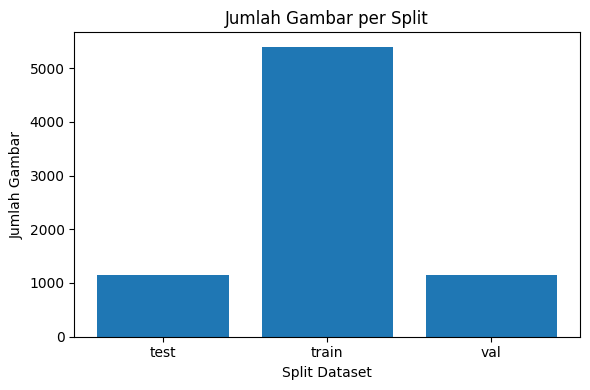

In [7]:
jumlah_per_split = df.groupby("split").size().reset_index(name="jumlah_gambar")
jumlah_per_split

plt.figure(figsize=(6, 4))
plt.bar(jumlah_per_split["split"], jumlah_per_split["jumlah_gambar"])
plt.title("Jumlah Gambar per Split")
plt.xlabel("Split Dataset")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "jumlah_gambar_per_split.png", dpi=300)
plt.show()

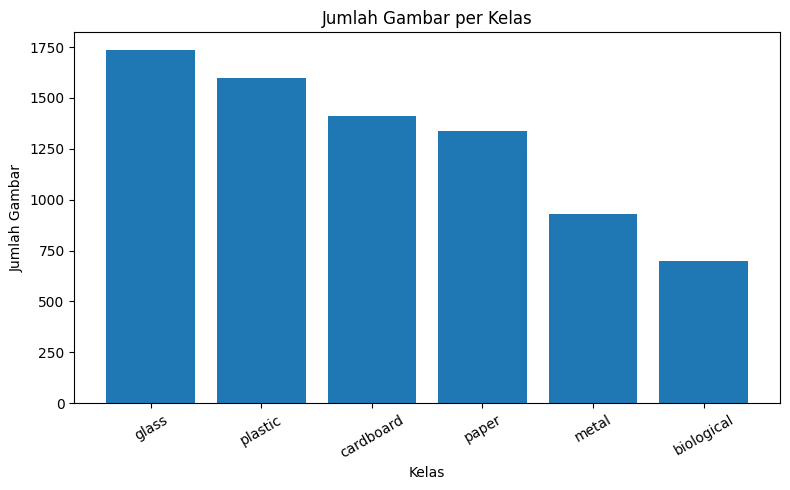

In [8]:
jumlah_per_kelas = df.groupby("kelas").size().reset_index(name="jumlah_gambar")
jumlah_per_kelas = jumlah_per_kelas.sort_values("jumlah_gambar", ascending=False)
jumlah_per_kelas

plt.figure(figsize=(8, 5))
plt.bar(jumlah_per_kelas["kelas"], jumlah_per_kelas["jumlah_gambar"])
plt.title("Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "jumlah_gambar_per_kelas.png", dpi=300)
plt.show()

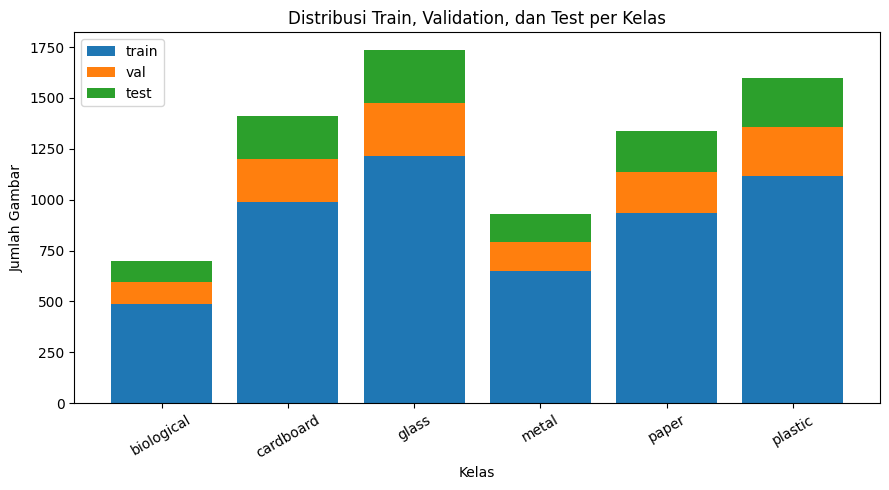

In [9]:
pivot_split_kelas = pd.pivot_table(
    df,
    index="kelas",
    columns="split",
    values="path",
    aggfunc="count",
    fill_value=0
)

pivot_split_kelas["total"] = pivot_split_kelas.sum(axis=1)
pivot_split_kelas

pivot_plot = pivot_split_kelas[["train", "val", "test"]]

plt.figure(figsize=(9, 5))
bottom = np.zeros(len(pivot_plot))

for split in ["train", "val", "test"]:
    plt.bar(pivot_plot.index, pivot_plot[split], bottom=bottom, label=split)
    bottom += pivot_plot[split].values

plt.title("Distribusi Train, Validation, dan Test per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "distribusi_split_per_kelas.png", dpi=300)
plt.show()

In [10]:
total_data = len(df)

rasio_split = jumlah_per_split.copy()
rasio_split["persentase"] = rasio_split["jumlah_gambar"] / total_data * 100

rasio_split

for _, row in rasio_split.iterrows():
    print(f"{row['split']}: {row['jumlah_gambar']} gambar ({row['persentase']:.2f}%)")

test: 1157 gambar (15.01%)
train: 5396 gambar (70.00%)
val: 1156 gambar (15.00%)


**EDA Image Quality**

In [11]:
corrupt_images = df[df["corrupt"] == True]

print("Jumlah gambar corrupt:", len(corrupt_images))
corrupt_images[["split", "kelas", "path", "error"]].head()

Jumlah gambar corrupt: 0


,split,kelas,path,error


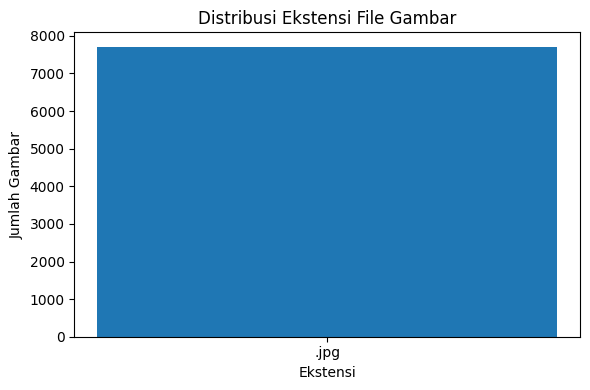

In [12]:
format_count = df.groupby(["format", "ekstensi"]).size().reset_index(name="jumlah")
format_count

format_simple = df.groupby("ekstensi").size().reset_index(name="jumlah")

plt.figure(figsize=(6, 4))
plt.bar(format_simple["ekstensi"], format_simple["jumlah"])
plt.title("Distribusi Ekstensi File Gambar")
plt.xlabel("Ekstensi")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "distribusi_ekstensi_file.png", dpi=300)
plt.show()

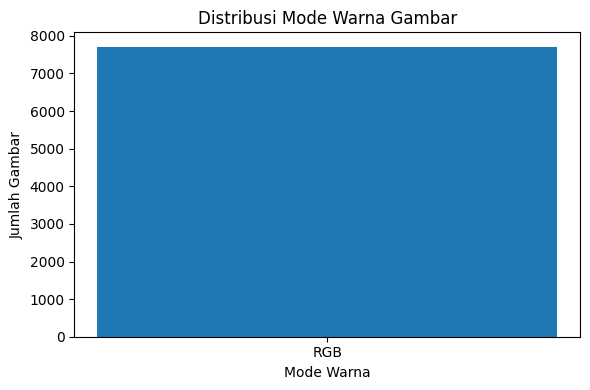

In [13]:
mode_count = df.groupby("mode").size().reset_index(name="jumlah")
mode_count

plt.figure(figsize=(6, 4))
plt.bar(mode_count["mode"], mode_count["jumlah"])
plt.title("Distribusi Mode Warna Gambar")
plt.xlabel("Mode Warna")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "distribusi_mode_warna.png", dpi=300)
plt.show()

**EDA Ukuran dan Image Resolution**

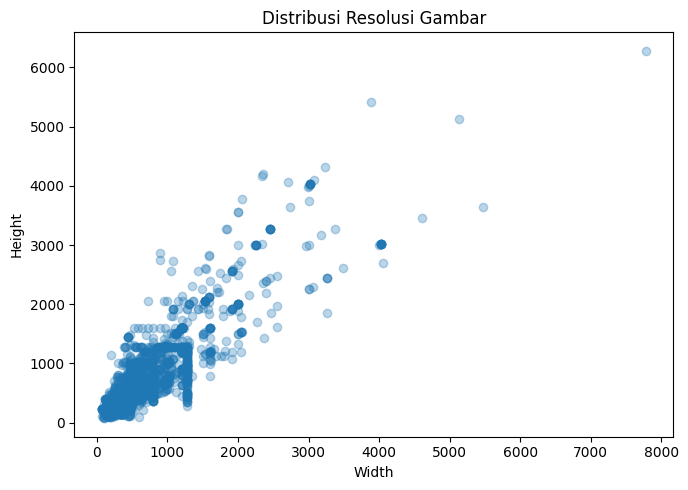

In [14]:
df[["width", "height", "aspect_ratio", "ukuran_file_kb"]].describe()

plt.figure(figsize=(7, 5))
plt.scatter(df["width"], df["height"], alpha=0.3)
plt.title("Distribusi Resolusi Gambar")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "distribusi_resolusi_gambar.png", dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7652\43685526.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_width, labels=kelas_unik)


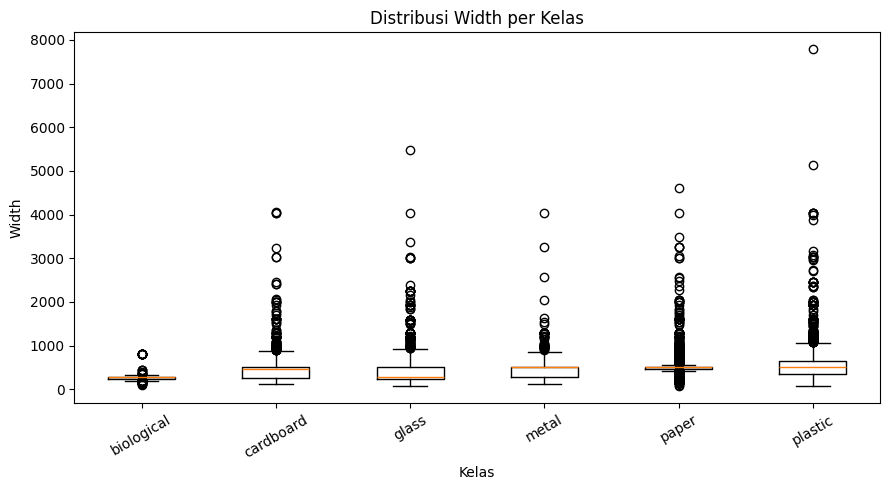

In [15]:
kelas_unik = sorted(df["kelas"].unique())

data_width = [df[df["kelas"] == k]["width"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_width, labels=kelas_unik)
plt.title("Distribusi Width per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Width")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_width_per_kelas.png", dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7652\1968036471.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_height, labels=kelas_unik)


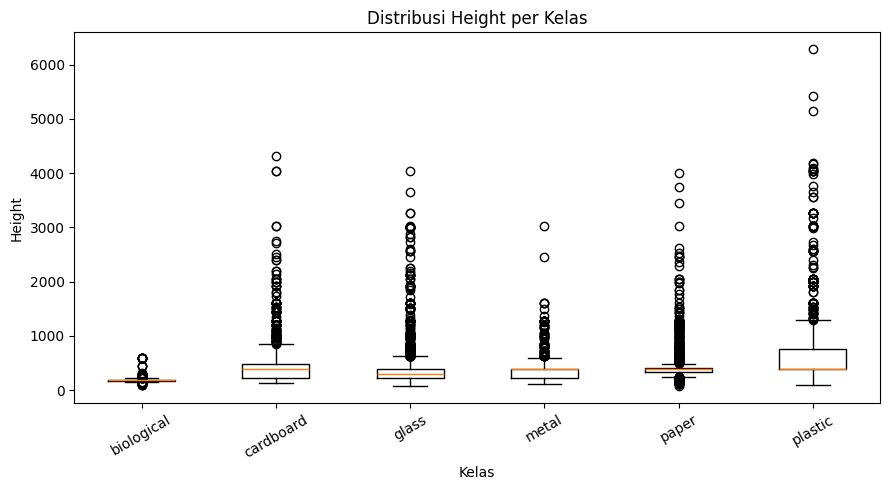

In [16]:
data_height = [df[df["kelas"] == k]["height"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_height, labels=kelas_unik)
plt.title("Distribusi Height per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Height")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_height_per_kelas.png", dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7652\469203291.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_aspect, labels=kelas_unik)


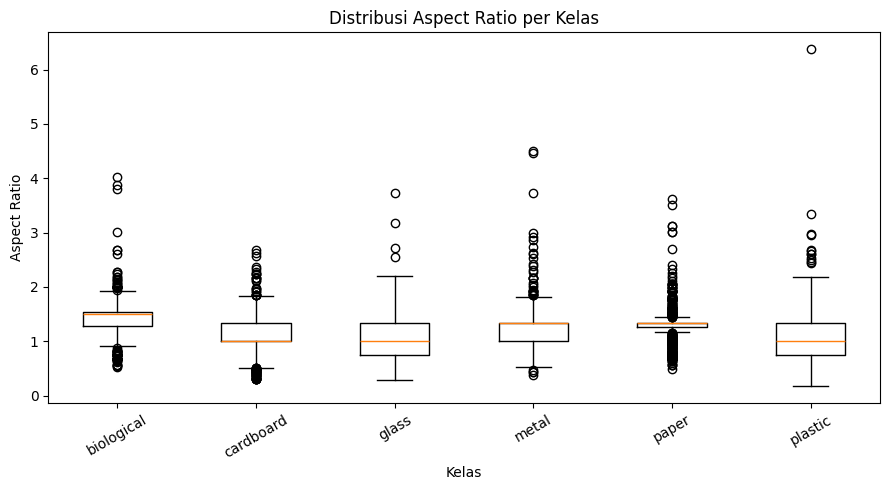

In [17]:
df[["kelas", "aspect_ratio"]].groupby("kelas").describe()

data_aspect = [df[df["kelas"] == k]["aspect_ratio"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_aspect, labels=kelas_unik)
plt.title("Distribusi Aspect Ratio per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Aspect Ratio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_aspect_ratio_per_kelas.png", dpi=300)
plt.show()

        notes:
        Aspect ratio mendekati 1 berarti gambar hampir persegi
        Aspect ratio > 1 berarti gambar lebih lebar
        Aspect ratio < 1 berarti gambar lebih tinggi

        ini dipake untuk resize

**EDA Visual Sample**

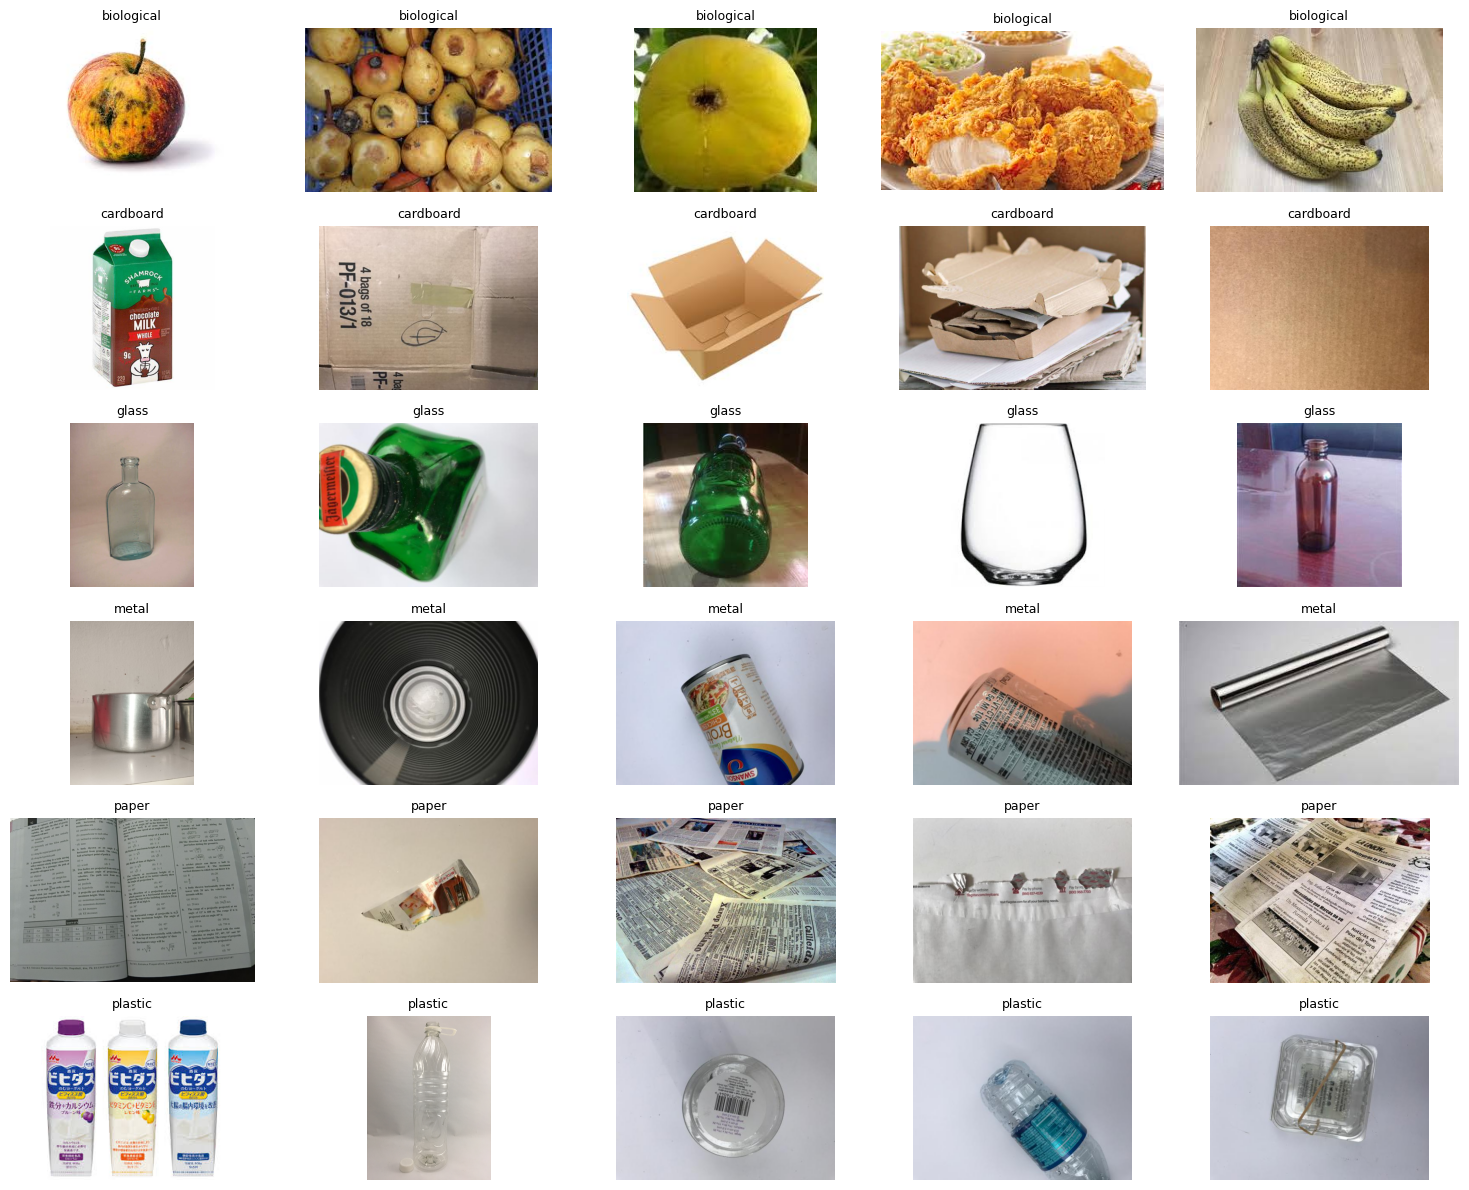

In [18]:
def tampilkan_sample_per_kelas(split="train", jumlah_per_kelas=5):
    plt.figure(figsize=(15, 12))

    index_plot = 1

    for nama_kelas in CLASSES:
        folder_kelas = DATA_DIR / split / nama_kelas
        daftar_gambar = [
            p for p in folder_kelas.iterdir()
            if p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        sample_gambar = random.sample(
            daftar_gambar,
            min(jumlah_per_kelas, len(daftar_gambar))
        )

        for path_gambar in sample_gambar:
            img = Image.open(path_gambar).convert("RGB")

            plt.subplot(len(CLASSES), jumlah_per_kelas, index_plot)
            plt.imshow(img)
            plt.title(nama_kelas, fontsize=9)
            plt.axis("off")

            index_plot += 1

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"sample_gambar_{split}.png", dpi=300)
    plt.show()


tampilkan_sample_per_kelas(split="train", jumlah_per_kelas=5)

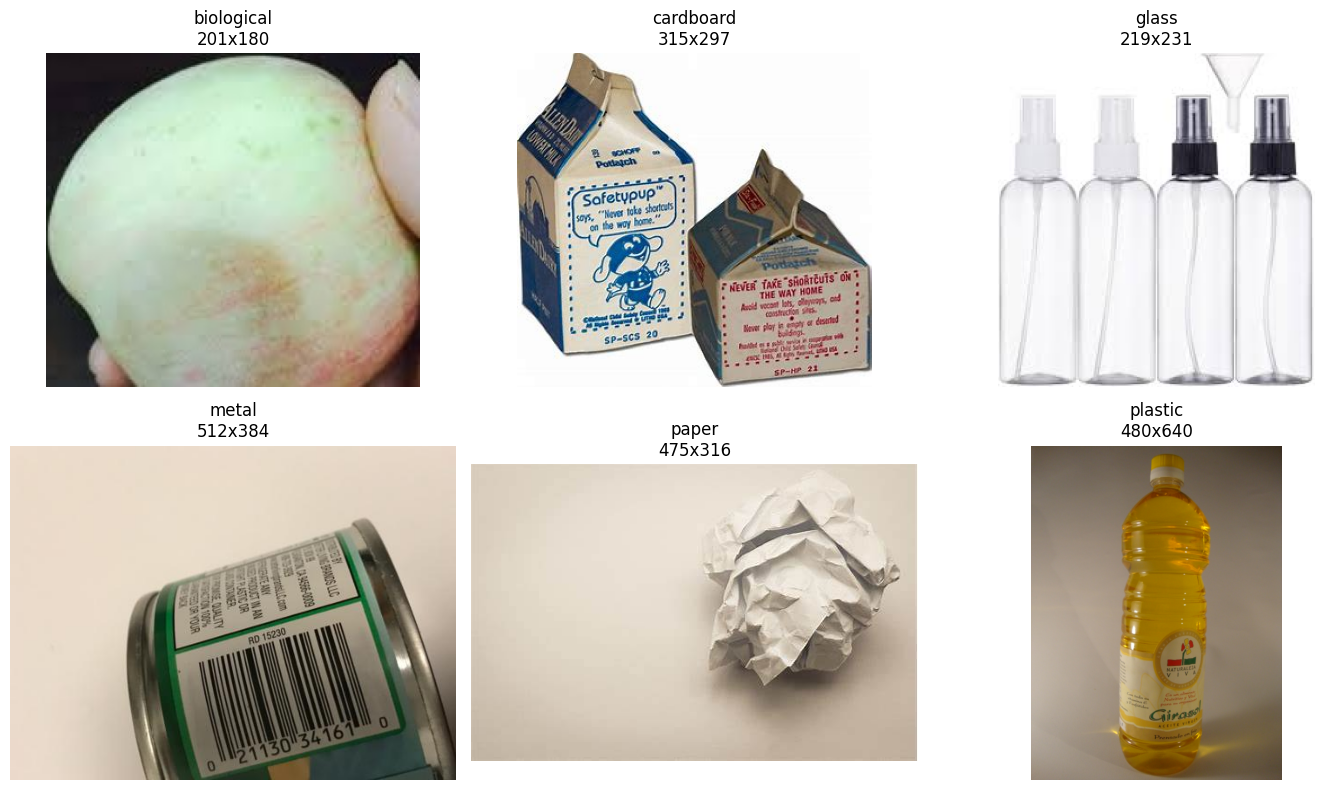

In [19]:
plt.figure(figsize=(14, 8))

for i, nama_kelas in enumerate(CLASSES):
    sample = df[(df["split"] == "train") & (df["kelas"] == nama_kelas)].sample(1).iloc[0]
    img = Image.open(sample["path"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{nama_kelas}\n{int(sample['width'])}x{int(sample['height'])}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "sample_gambar_dengan_ukuran.png", dpi=300)
plt.show()

**EDA Brightness, Contrast, dan Sharpness**
ini untuk nanti enhancement (ex: gaussian fillter)

C:\Users\User\AppData\Local\Temp\ipykernel_7652\1210850750.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_brightness, labels=kelas_unik)


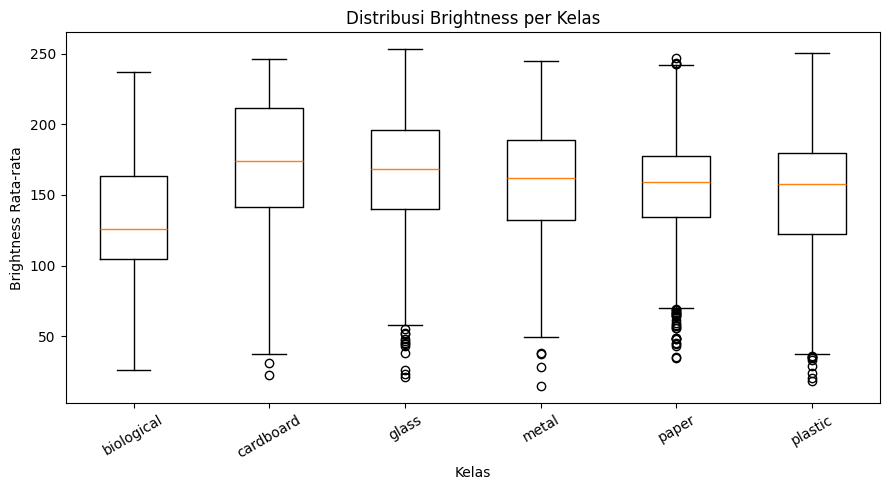

In [20]:
brightness_stat = df.groupby("kelas")["brightness"].describe()
brightness_stat

data_brightness = [df[df["kelas"] == k]["brightness"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_brightness, labels=kelas_unik)
plt.title("Distribusi Brightness per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Brightness Rata-rata")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_brightness_per_kelas.png", dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7652\1891622465.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_contrast, labels=kelas_unik)


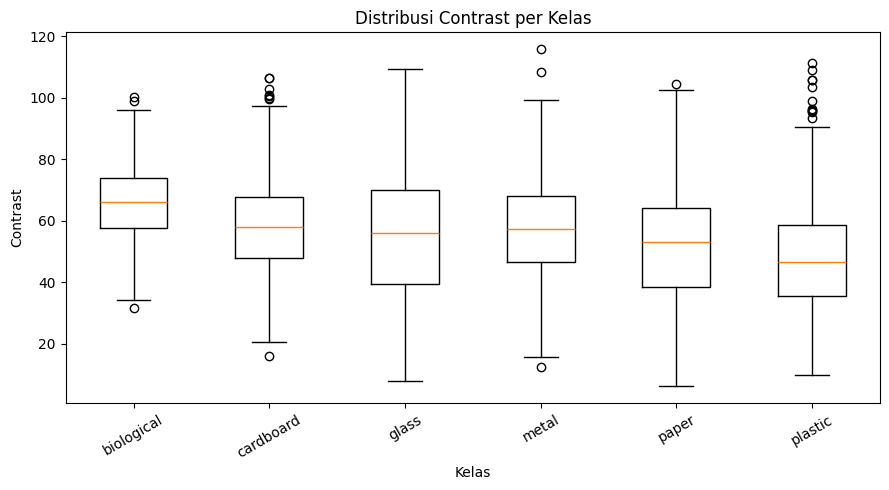

In [21]:
contrast_stat = df.groupby("kelas")["contrast"].describe()
contrast_stat

data_contrast = [df[df["kelas"] == k]["contrast"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_contrast, labels=kelas_unik)
plt.title("Distribusi Contrast per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Contrast")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_contrast_per_kelas.png", dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7652\3662058016.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_sharpness, labels=kelas_unik)


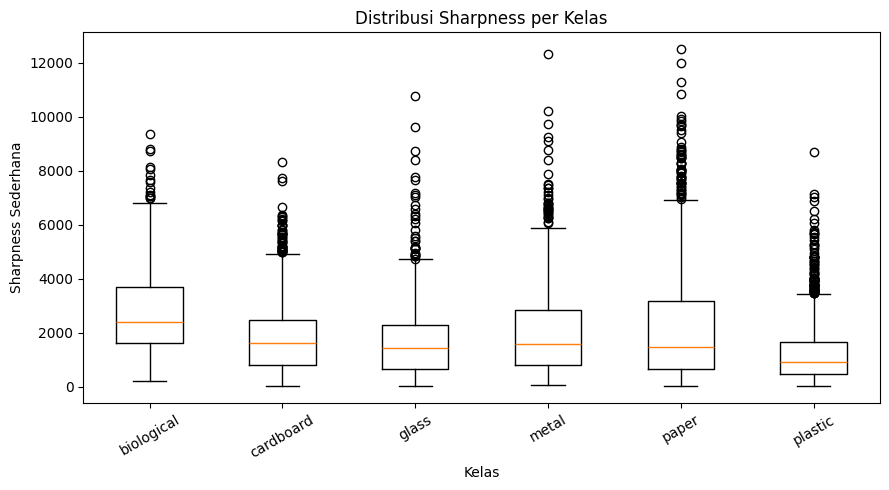

In [22]:
sharpness_stat = df.groupby("kelas")["sharpness"].describe()
sharpness_stat

data_sharpness = [df[df["kelas"] == k]["sharpness"].dropna() for k in kelas_unik]

plt.figure(figsize=(9, 5))
plt.boxplot(data_sharpness, labels=kelas_unik)
plt.title("Distribusi Sharpness per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Sharpness Sederhana")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_sharpness_per_kelas.png", dpi=300)
plt.show()

**EDA Warna RGB**

In [23]:
def hitung_mean_rgb(path_gambar):
    img = Image.open(path_gambar).convert("RGB")
    arr = np.array(img)

    mean_r = arr[:, :, 0].mean()
    mean_g = arr[:, :, 1].mean()
    mean_b = arr[:, :, 2].mean()

    return mean_r, mean_g, mean_b


mean_r_list = []
mean_g_list = []
mean_b_list = []

for path in df["path"]:
    r, g, b = hitung_mean_rgb(path)
    mean_r_list.append(r)
    mean_g_list.append(g)
    mean_b_list.append(b)

df["mean_R"] = mean_r_list
df["mean_G"] = mean_g_list
df["mean_B"] = mean_b_list

df[["kelas", "mean_R", "mean_G", "mean_B"]].head()

df.to_csv(RESULT_DIR / "metadata_gambar_lengkap.csv", index=False)

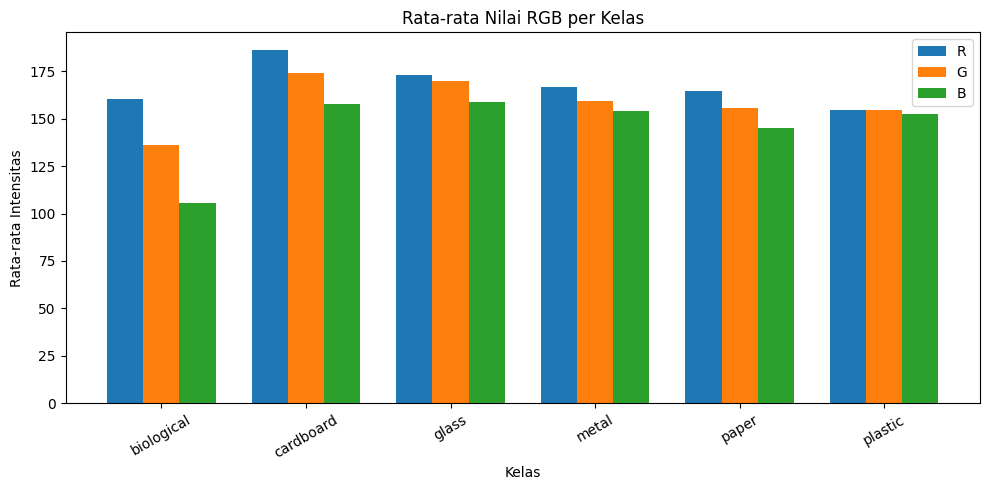

In [24]:
rgb_per_kelas = df.groupby("kelas")[["mean_R", "mean_G", "mean_B"]].mean()
rgb_per_kelas

x = np.arange(len(rgb_per_kelas.index))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, rgb_per_kelas["mean_R"], width, label="R")
plt.bar(x, rgb_per_kelas["mean_G"], width, label="G")
plt.bar(x + width, rgb_per_kelas["mean_B"], width, label="B")

plt.title("Rata-rata Nilai RGB per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Rata-rata Intensitas")
plt.xticks(x, rgb_per_kelas.index, rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rata_rata_rgb_per_kelas.png", dpi=300)
plt.show()

# Kalau punya pola warna dominan, model bisa lebih ez bedainnya
# Tapi kalau warna kelas mirip, misalnya paper dan plastic, model butuh fitur lain ex: tekstur dan bentuk

**EDA Duplikasi Gambar**

In [25]:
duplikat = df[df.duplicated(subset="md5", keep=False)].sort_values("md5")

print("Jumlah gambar yang terindikasi duplikat exact:", len(duplikat))
duplikat[["split", "kelas", "nama_file", "path", "md5"]].head(20)

duplikat_lintas_split = (
    duplikat
    .groupby("md5")
    .agg(
        jumlah=("path", "count"),
        split_unik=("split", lambda x: list(set(x))),
        kelas_unik=("kelas", lambda x: list(set(x))),
        path=("path", list)
    )
    .reset_index()
)

duplikat_lintas_split["jumlah_split_unik"] = duplikat_lintas_split["split_unik"].apply(len)

duplikat_lintas_split = duplikat_lintas_split[
    duplikat_lintas_split["jumlah_split_unik"] > 1
]

print("Jumlah duplikat yang muncul lintas split:", len(duplikat_lintas_split))
duplikat_lintas_split.head()

Jumlah gambar yang terindikasi duplikat exact: 0
Jumlah duplikat yang muncul lintas split: 0


,md5,jumlah,split_unik,kelas_unik,path,jumlah_split_unik


**EDA Outlier**

In [26]:
# Threshold sederhana, bisa disesuaikan
outlier_kecil = df[(df["width"] < 100) | (df["height"] < 100)]
outlier_besar = df[(df["width"] > 3000) | (df["height"] > 3000)]
outlier_gelap = df[df["brightness"] < 40]
outlier_terang = df[df["brightness"] > 220]
outlier_blur = df[df["sharpness"] < df["sharpness"].quantile(0.05)]

print("Gambar terlalu kecil:", len(outlier_kecil))
print("Gambar terlalu besar:", len(outlier_besar))
print("Gambar terlalu gelap:", len(outlier_gelap))
print("Gambar terlalu terang:", len(outlier_terang))
print("Gambar paling blur 5% terbawah:", len(outlier_blur))

Gambar terlalu kecil: 29
Gambar terlalu besar: 53
Gambar terlalu gelap: 30
Gambar terlalu terang: 784
Gambar paling blur 5% terbawah: 386


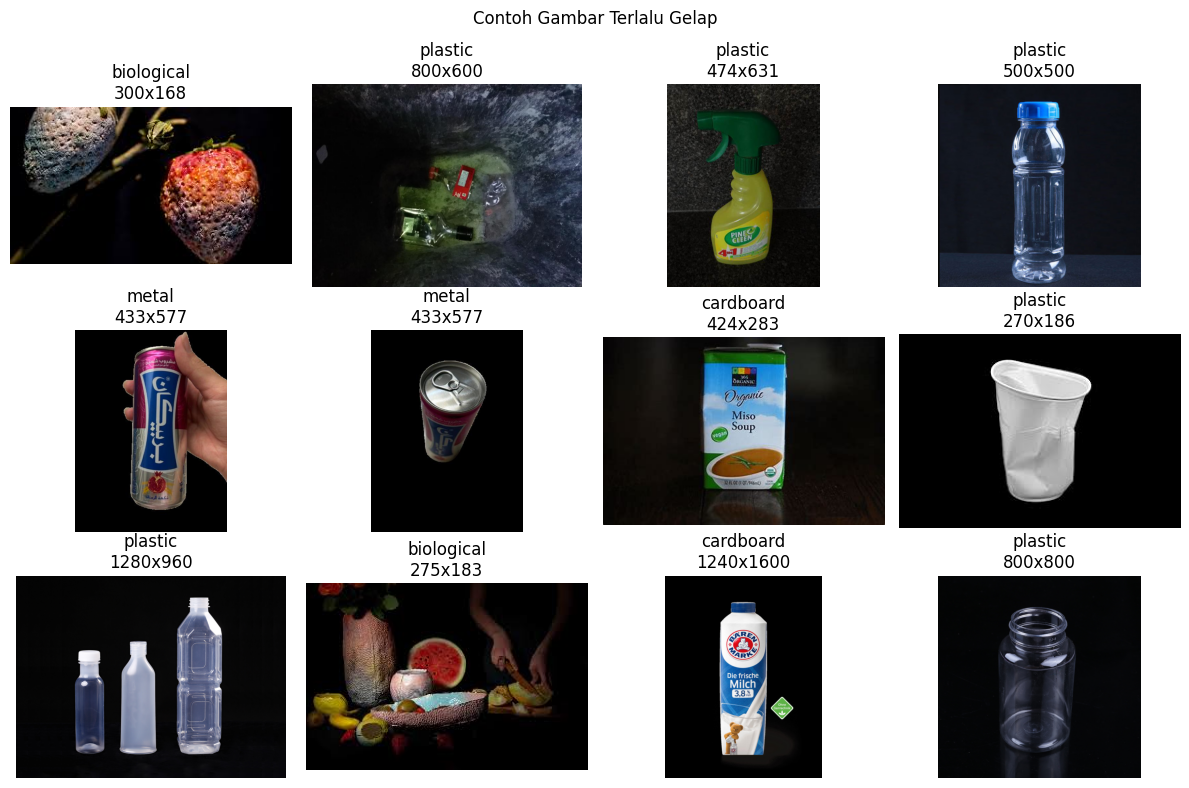

In [27]:
# Outlier Gelap
def tampilkan_outlier(dataframe, judul, jumlah=12):
    if len(dataframe) == 0:
        print("Tidak ada outlier untuk:", judul)
        return

    sample_df = dataframe.sample(min(jumlah, len(dataframe)), random_state=42)

    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{row['kelas']}\n{row['width']}x{row['height']}")
        plt.axis("off")

    plt.suptitle(judul)
    plt.tight_layout()
    plt.show()


tampilkan_outlier(outlier_gelap, "Contoh Gambar Terlalu Gelap")

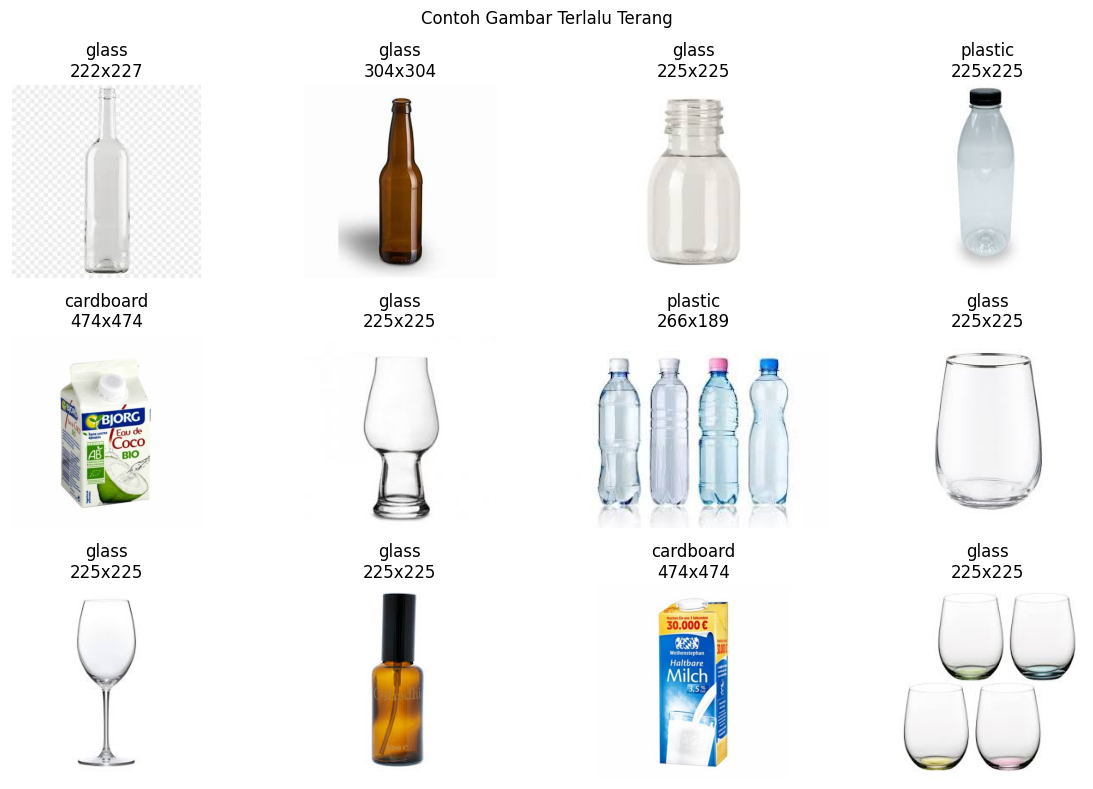

In [28]:
# Outlier Terang
tampilkan_outlier(outlier_terang, "Contoh Gambar Terlalu Terang")

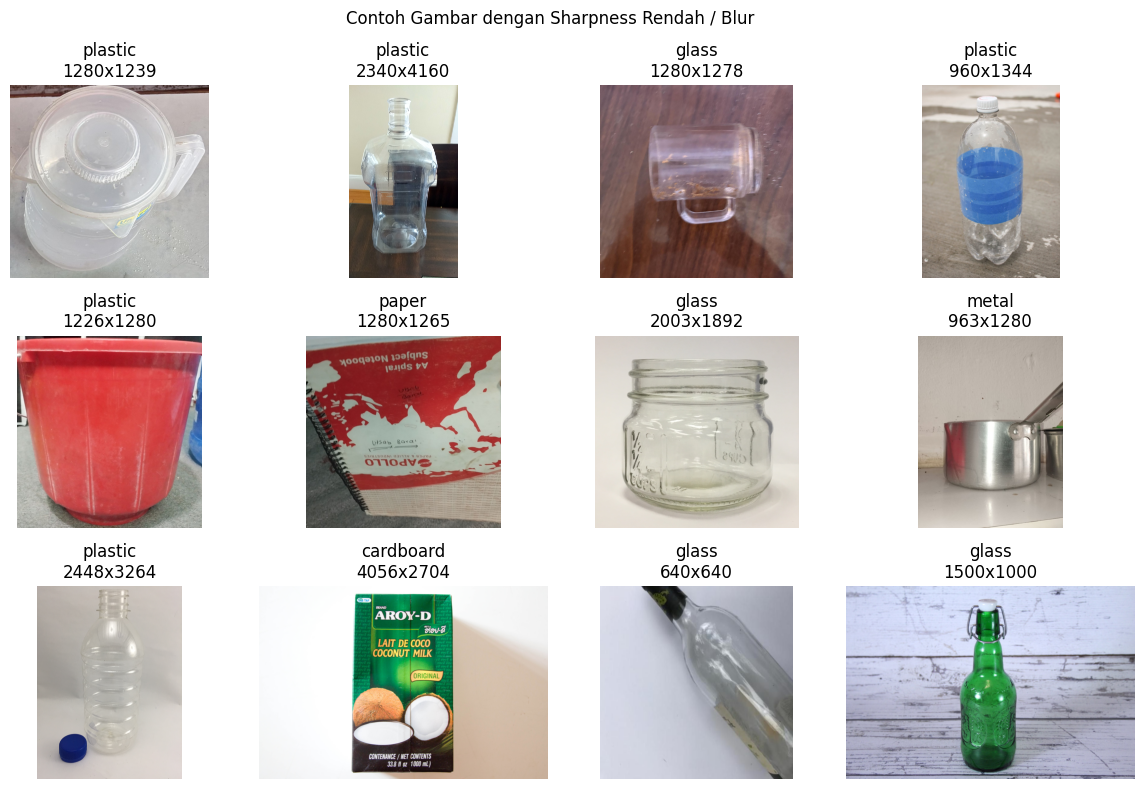

In [29]:
# Outlier Blur
tampilkan_outlier(outlier_blur, "Contoh Gambar dengan Sharpness Rendah / Blur")

**EDA Perbandingan Sebelum Resize**

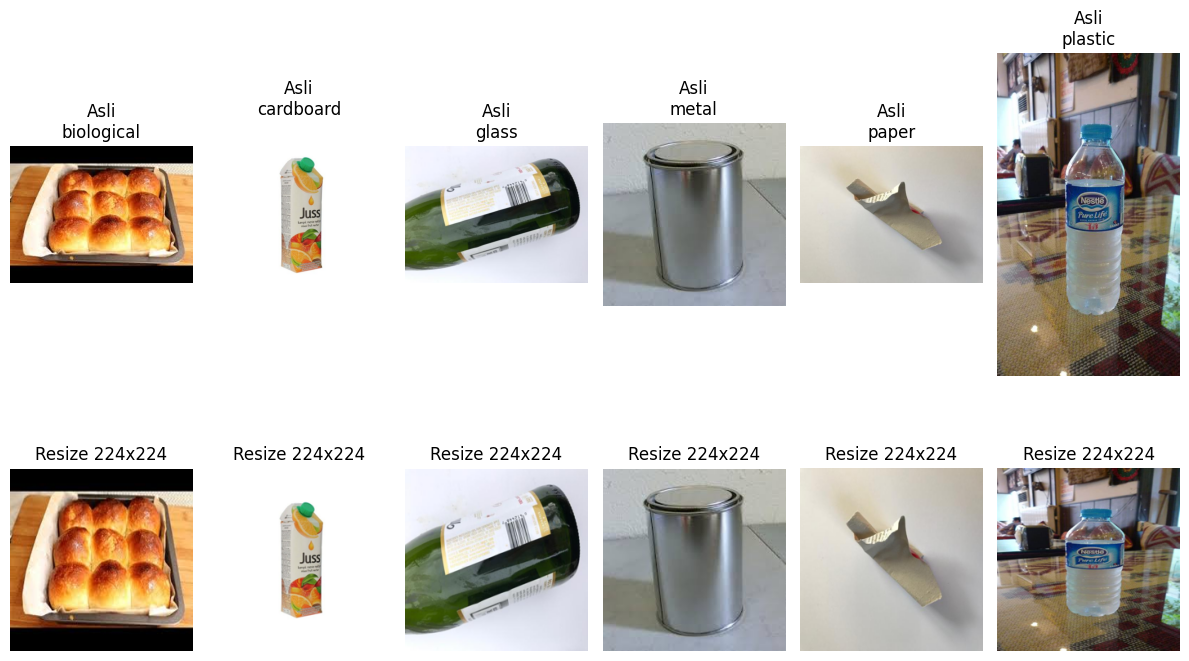

In [30]:
# Simulasi resize contoh gambar ke 224x224
plt.figure(figsize=(12, 8))

for i, nama_kelas in enumerate(CLASSES):
    sample = df[(df["split"] == "train") & (df["kelas"] == nama_kelas)].sample(1).iloc[0]

    img_asli = Image.open(sample["path"]).convert("RGB")
    img_resize = img_asli.resize((224, 224))

    plt.subplot(2, 6, i + 1)
    plt.imshow(img_asli)
    plt.title(f"Asli\n{nama_kelas}")
    plt.axis("off")

    plt.subplot(2, 6, i + 7)
    plt.imshow(img_resize)
    plt.title("Resize 224x224")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "preview_resize_224.png", dpi=300)
plt.show()

**Summary**

In [31]:
summary = {}

summary["total_gambar"] = len(df)
summary["jumlah_kelas"] = df["kelas"].nunique()
summary["kelas"] = sorted(df["kelas"].unique().tolist())
summary["jumlah_train"] = len(df[df["split"] == "train"])
summary["jumlah_val"] = len(df[df["split"] == "val"])
summary["jumlah_test"] = len(df[df["split"] == "test"])
summary["jumlah_corrupt"] = len(df[df["corrupt"] == True])
summary["width_min"] = df["width"].min()
summary["width_max"] = df["width"].max()
summary["height_min"] = df["height"].min()
summary["height_max"] = df["height"].max()
summary["brightness_mean"] = df["brightness"].mean()
summary["contrast_mean"] = df["contrast"].mean()
summary["sharpness_mean"] = df["sharpness"].mean()

for key, value in summary.items():
    print(f"{key}: {value}")

with open(RESULT_DIR / "ringkasan_eda.txt", "w", encoding="utf-8") as f:
    for key, value in summary.items():
        f.write(f"{key}: {value}\n")

print("Ringkasan EDA disimpan ke:", RESULT_DIR / "ringkasan_eda.txt")

total_gambar: 7709
jumlah_kelas: 6
kelas: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
jumlah_train: 5396
jumlah_val: 1156
jumlah_test: 1157
jumlah_corrupt: 0
width_min: 68
width_max: 7786
height_min: 71
height_max: 6283
brightness_mean: 159.5589113330666
contrast_mean: 54.95738350636902
sharpness_mean: 1861.3527987677228
Ringkasan EDA disimpan ke: ..\results\eda\ringkasan_eda.txt


**Summary per class**

In [33]:
ringkasan_per_kelas = df.groupby("kelas").agg(
    jumlah_gambar=("path", "count"),
    rata_width=("width", "mean"),
    rata_height=("height", "mean"),
    rata_aspect_ratio=("aspect_ratio", "mean"),
    rata_brightness=("brightness", "mean"),
    rata_contrast=("contrast", "mean"),
    rata_sharpness=("sharpness", "mean"),
    rata_R=("mean_R", "mean"),
    rata_G=("mean_G", "mean"),
    rata_B=("mean_B", "mean")
).reset_index()

ringkasan_per_kelas

ringkasan_per_kelas.to_csv(RESULT_DIR / "ringkasan_per_kelas.csv", index=False)